In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.rcParams['font.family'] = 'Malgun Gothic'

In [45]:
df_original = pd.read_excel('2_Security_Disclosure_Compliance_List_English.xlsx')
df = df_original.copy()
df

,Disclosure_Year(yyyy),Company_Name_K,Company_Name_E,Industry,Disclosure obligation,Pre-inspection Status,IT_Investment(A),Security_Investment(B),Key Investment Items,Investment_Ratio(B/A),...,CPO Position Name,CPO_Executive,CPO_Dual_Role,No. of Major CPO Activities,Staffing Status_Notes,Security Certs/Eval,Security Activities,IS Disclosure Excellence,Security_Investment_Excellence(Yes/No),Revised Disclosure
0,2016,테크빌교육(주),Techville Education Co.,정보통신업(58~63),Voluntary,X,1.611476e+09,1.316896e+08,NaN,8.2,...,NaN,NaN,NaN,0.0,NaN,해당사항없음,"○ 정보보호 자격증 취득 지원, 교육, 보상_x000D_\n○ 정보보호 교육과정 개...",X,X,X
1,2016,삼성웰스토리,Sansumg WellStory,숙박 및 음식점업(55~56),Voluntary,X,2.071520e+10,1.278427e+09,NaN,6.2,...,NaN,NaN,NaN,0.0,NaN,○ 정보보호 관리체계_x000D_\n○ 개인정보보호 관리체계,○ K-shield 인증 취득 1명_x000D_\n○ 임직원 보안의식 제고 추진 -...,X,O,X
2,2017,테크빌교육(주),Techville Education Co.,정보통신업(58~63),Voluntary,X,1.842954e+09,9.742605e+07,NaN,5.3,...,NaN,NaN,NaN,0.0,NaN,해당사항없음,○ 정보보호담당자 정보보호 전문교육 이수 지원_x000D_\n○ WAF보안장비 도입...,X,X,X
3,2017,LG유플러스,LG Uplus,정보통신업(58~63),Voluntary,X,5.450000e+11,1.870216e+10,NaN,3.4,...,NaN,NaN,NaN,0.0,NaN,○ 정보보호 관리체계(2016년 11월 15일 ~ 2019년 11월 14일)_x00...,"○ U Cloud 전사적용(임직원, 대리점, 외주인력 포함)_x000D_\n○ 정보...",X,X,X
4,2017,(주)케이티,KT,정보통신업(58~63),Voluntary,X,2.062350e+12,9.100407e+10,NaN,4.4,...,NaN,NaN,NaN,0.0,NaN,"○ 정보보호 관리체계(ICS, 2016년 12월 16일 ~ 2019년 12월 15일...",○ 정보보호 자격증 취득 지원/보상_x000D_\n○ 보안성 승인 및 개인정보영향평...,X,X,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3061,2025,삼성전자(주),Samsung Electronics Co.,제조업(10~34),Mandatory,X,6.659820e+12,3.477988e+11,NaN,5.2,...,부사장,O,X,2.0,NaN,- ISMS_x000D_\n- ISO/IEC 27001_x000D_\n- ISO/I...,- 정보보호 규정 홍보_x000D_\n- 임직원 정기 정보보호 교육 진행_x000D...,X,O,O
3062,2025,순천향대학교부속천안병원,Sunchunhyang University Cheonan Hospital,교육 서비스업(85),Voluntary,X,5.171689e+09,6.041068e+08,전산도급비,11.7,...,팀장,X,O,2.0,NaN,1. ISMS 정보보호 관리체계 인증_x000D_\n2. EMR 전자의무기록시스템 ...,1. 정보보호 뉴스레터 및 퀴즈 포상_x000D_\n2. 개인정보처리시스템 모니터링...,X,O,X
3063,2026,숭실대학교,Sungsil University,교육 서비스업(85),Voluntary,X,4.005755e+09,3.765494e+08,정보시스템 유지보수,9.4,...,부총장,O,O,0.0,없음,ISMS-P(정보보호 및 개인정보보호 관리체계),▶ ISMS-P 재인증_x000D_\n▶ KISA 주관 사이버 위기 대응 모의훈련_...,X,X,X
3064,2026,성균관대학교,Sungkyunkwan University,교육 서비스업(85),Voluntary,X,9.217931e+09,3.242200e+08,유지보수 및 시스템 구축,3.5,...,처장,O,O,0.0,없음,○ ISMS(정보보호 관리체계),○ 버그바운티(보안취약점 검출 대회) 실시_x000D_\n○ 침해사고 대응 모의훈련...,X,O,X


In [46]:
df.columns

Index(['Disclosure_Year(yyyy)', 'Company_Name_K', 'Company_Name_E', 'Industry',
       'Disclosure obligation', 'Pre-inspection Status', 'IT_Investment(A)',
       'Security_Investment(B)', 'Key Investment Items',
       'Investment_Ratio(B/A)', 'Investement Status_Notes', 'Total_Employees',
       'IT_Workforce(C)', 'Internal_Security_Staff', 'External_Security_Staff',
       'Security_Workforce(D)', 'Security_Workforce_Ratio(D/C)',
       'CISO Position Name', 'CISO_Executive', 'CISO_Dual_Role',
       'No. of Major CISO Activities', 'CPO Position Name', 'CPO_Executive',
       'CPO_Dual_Role', 'No. of Major CPO Activities', 'Staffing Status_Notes',
       'Security Certs/Eval', 'Security Activities',
       'IS Disclosure Excellence', 'Security_Investment_Excellence(Yes/No)',
       'Revised Disclosure'],
      dtype='object')

1. 공시제도의 유효성

1.1 2022년 공시 제도 도입 이후 공시 참여 기업 수가 증가하였는가? 

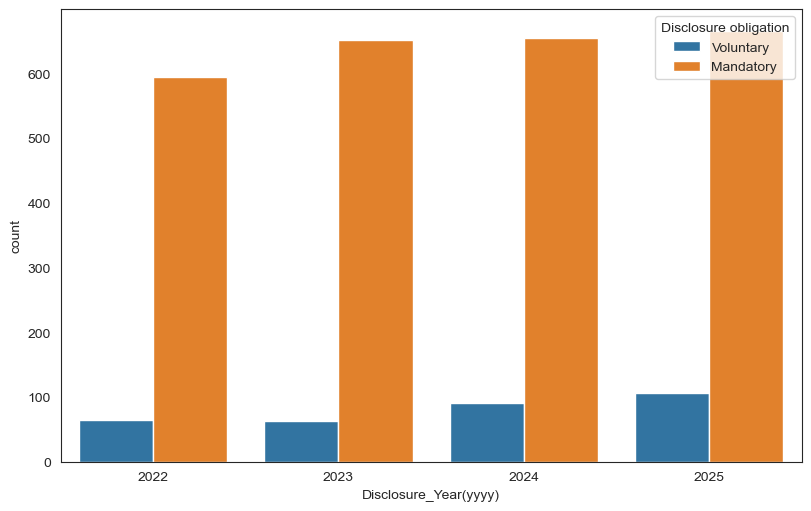

In [47]:
df_2022 = df[(df['Disclosure_Year(yyyy)'] >= 2022) & (df['Disclosure_Year(yyyy)'] < 2026)].copy()
sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
sns.countplot(x='Disclosure_Year(yyyy)', hue='Disclosure obligation', data=df_2022, ax=ax)
plt.show()

1.2 2022년 공시 제도 도입 이후 보안 투자율이 증가하였는가? 

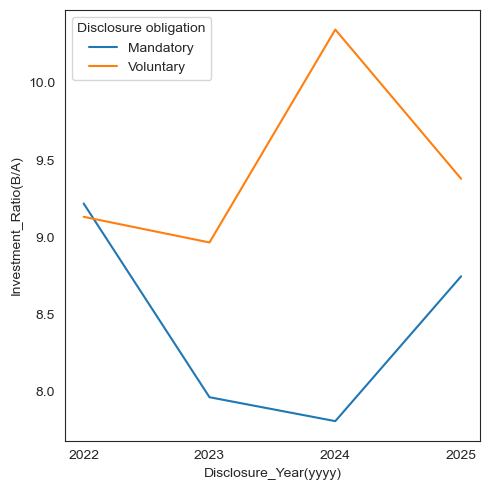

In [48]:
y_mean = df_2022.groupby(['Disclosure_Year(yyyy)', 'Disclosure obligation'])['Investment_Ratio(B/A)'].mean().reset_index()
sns.set_style("white")
plt.figure(figsize=(5, 5))
sns.lineplot(data=y_mean, x='Disclosure_Year(yyyy)', y='Investment_Ratio(B/A)', hue='Disclosure obligation')
plt.xticks(y_mean['Disclosure_Year(yyyy)'].unique())
plt.tight_layout()
plt.show()

1.3 의무 공시 기업은 자율 공시 기업보다 보안 투자를 더 많이 하는가?

<Figure size 1200x600 with 0 Axes>

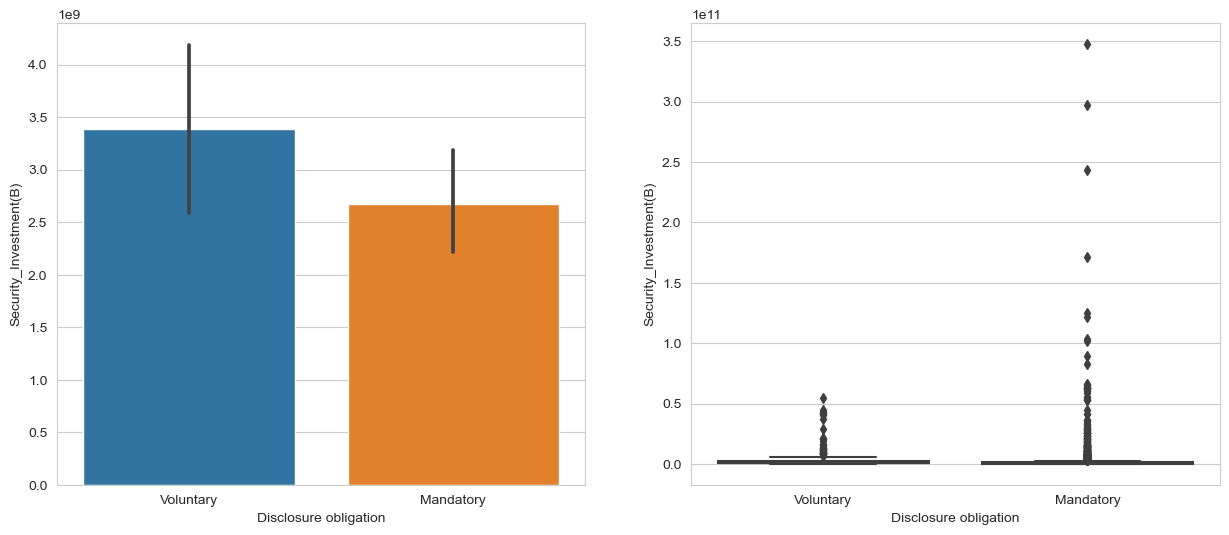

In [49]:
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=df_2022, x='Disclosure obligation', y='Security_Investment(B)', ax=ax1)
sns.boxplot(data=df_2022, x='Disclosure obligation', y='Security_Investment(B)', ax=ax2)
plt.show()

1.4 의무 공시 기업은 자율 공시 기업보다 정정 공시 비율이 낮은가?

<Figure size 1200x600 with 0 Axes>

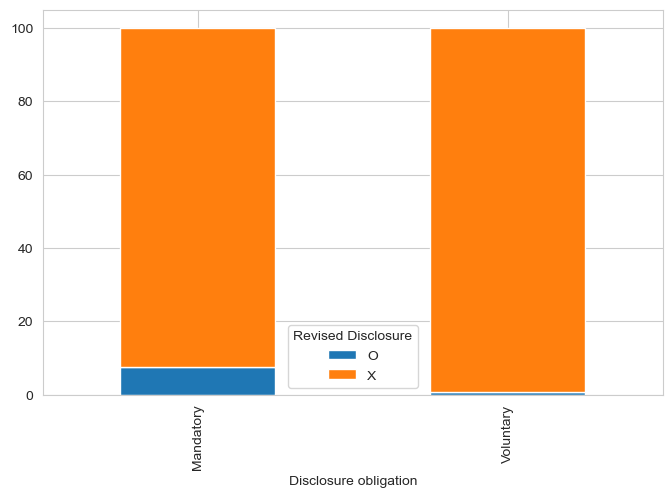

In [50]:
df_disclosure= df.groupby('Disclosure obligation')['Revised Disclosure'].value_counts(normalize=True).unstack().fillna(0) * 100
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))
ax = df_disclosure.plot(kind='bar', stacked=True, figsize=(8,5))
plt.show()

1.5 투자 우수 기업의 실제 투자율은 선정 기준치인 5%와 편차가 어느 정도인가?(턱걸이 투자 확인)

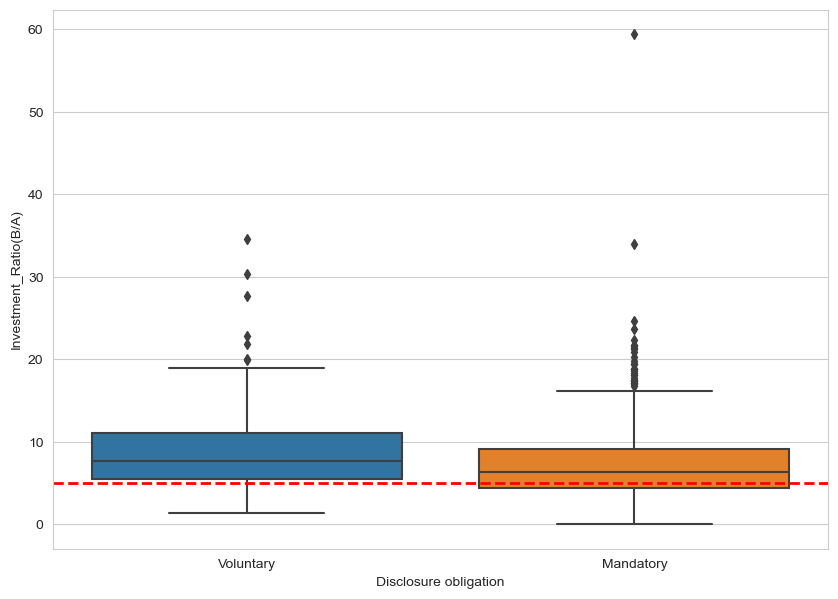

In [51]:
df_excellence = df[df['Security_Investment_Excellence(Yes/No)'] == 'O'].copy()
sns.set_style("whitegrid")
plt.figure(figsize=(10, 7))
ax = sns.boxplot(data=df_excellence, x='Disclosure obligation', y='Investment_Ratio(B/A)')
plt.axhline(y=5.0, color='r', linestyle='--', linewidth=2)
plt.show()

2. 산업별 보안투자

2.1 산업별로 보안 투자율이 어떠한가?

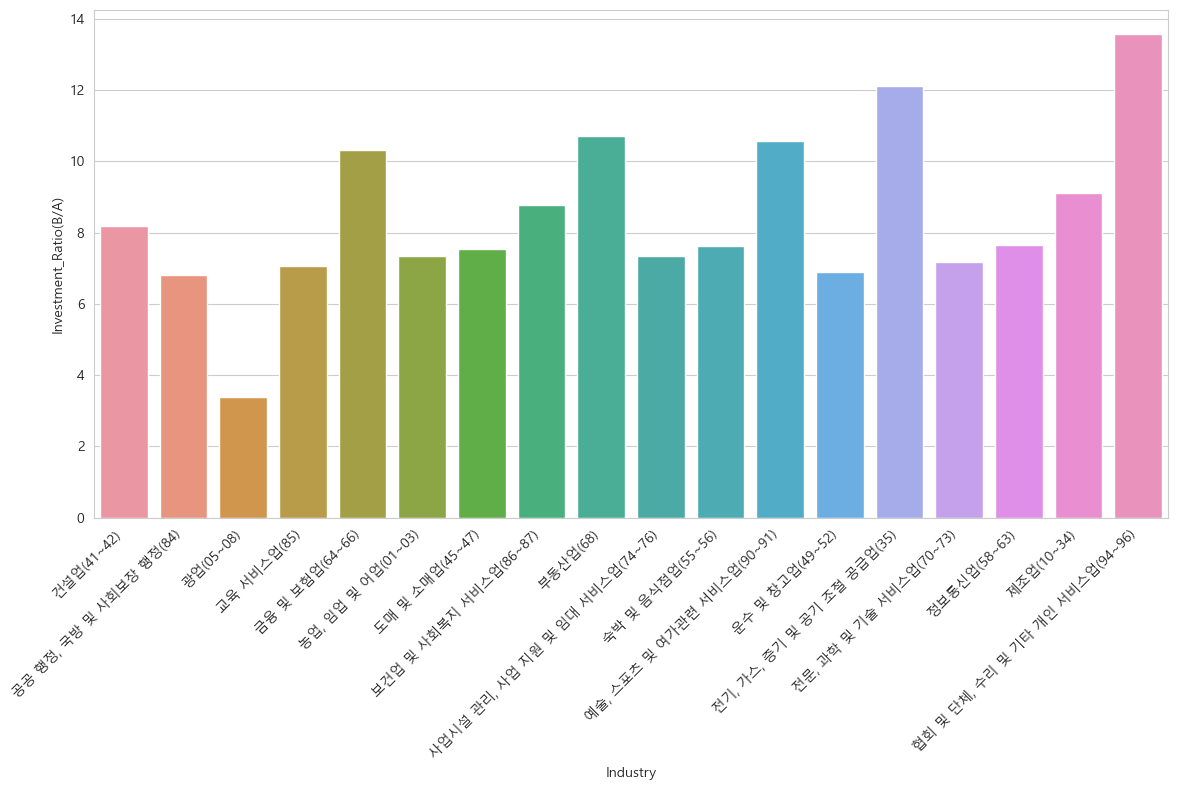

In [55]:
df_industry = df.groupby('Industry')['Investment_Ratio(B/A)'].mean().reset_index()
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=df_industry, x='Industry', y='Investment_Ratio(B/A)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

2.2 보안 투자율 상위권 산업군과 하위 산업군 사이의 연도별 투자 격차가 어떠한가?

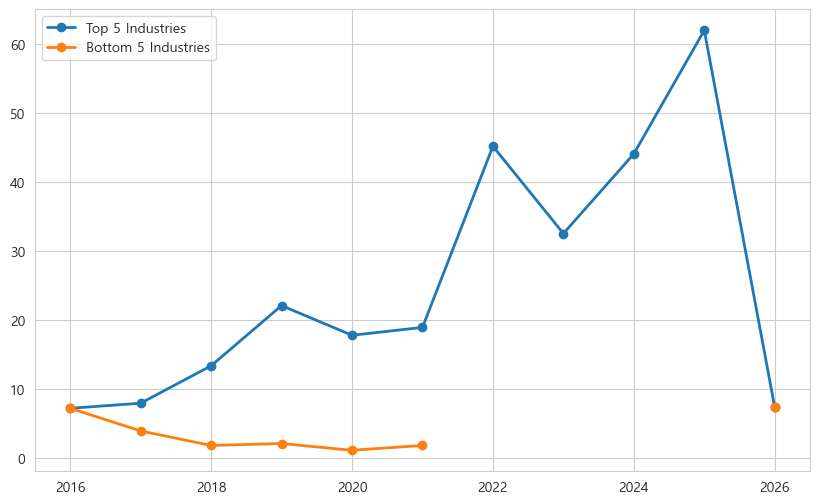

In [85]:
df_sorted = df.sort_values(['Disclosure_Year(yyyy)', 'Investment_Ratio(B/A)'], ascending=[True, False])
top_5 = df_sorted.groupby('Disclosure_Year(yyyy)').head(5)
bottom_5 = df_sorted.groupby('Disclosure_Year(yyyy)').tail(5)
top_avg = top_5.groupby('Disclosure_Year(yyyy)')['Investment_Ratio(B/A)'].mean().reset_index()
bottom_avg = bottom_5.groupby('Disclosure_Year(yyyy)')['Investment_Ratio(B/A)'].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(top_avg['Disclosure_Year(yyyy)'], top_avg['Investment_Ratio(B/A)'], label='Top 5 Industries', marker='o', linewidth=2)
plt.plot(bottom_avg['Disclosure_Year(yyyy)'], bottom_avg['Investment_Ratio(B/A)'],label='Bottom 5 Industries', marker='o', linewidth=2)
plt.legend()
plt.show()

3. 보안 추세

3.1 인력 투자(사람중심보안)와 IT투자(장비중심보안) 중 어디에 더 많이 투자하는 추세인가?

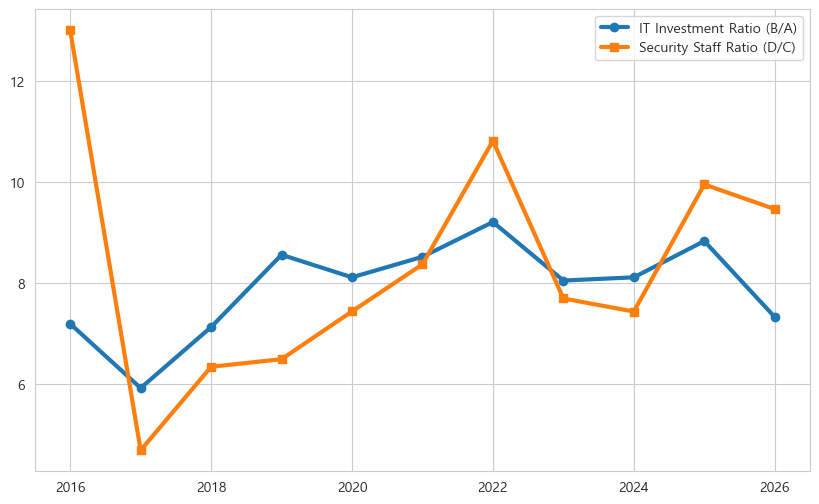

In [65]:
trend_df = df.groupby('Disclosure_Year(yyyy)')[['Investment_Ratio(B/A)', 'Security_Workforce_Ratio(D/C)']].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.plot(trend_df['Disclosure_Year(yyyy)'], trend_df['Investment_Ratio(B/A)'], 
         label='IT Investment Ratio (B/A)', marker='o', lw=3)
plt.plot(trend_df['Disclosure_Year(yyyy)'], trend_df['Security_Workforce_Ratio(D/C)'], 
         label='Security Staff Ratio (D/C)', marker='s', lw=3)
plt.legend()
plt.show()

3.2 CISO가 임원일수록 인력 투자가 늘어나는가, IT 투자가 늘어나는가?

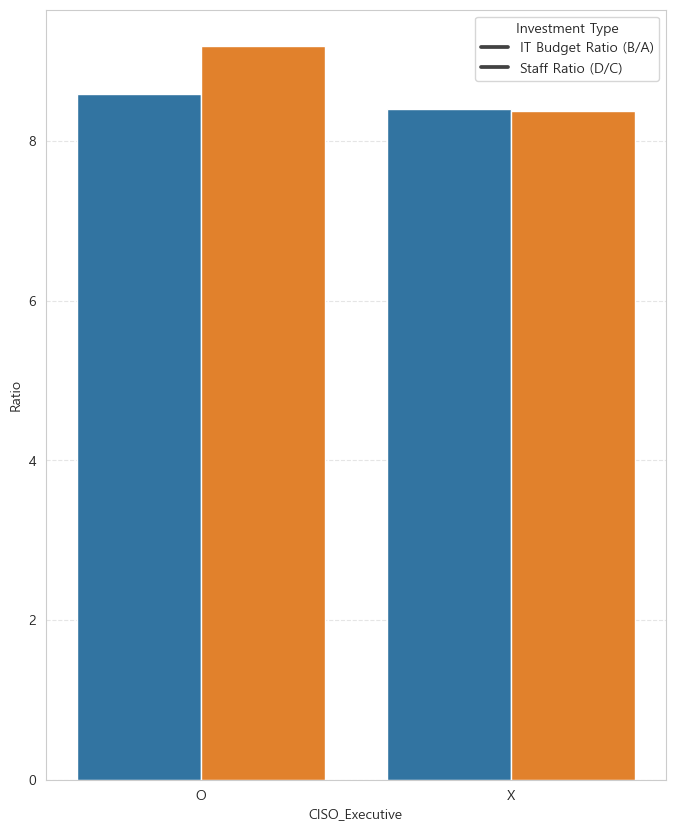

In [70]:
df_ciso = df.groupby('CISO_Executive')[['Investment_Ratio(B/A)', 'Security_Workforce_Ratio(D/C)']].mean().reset_index()
melted_df = df_ciso.melt(id_vars='CISO_Executive', value_vars=['Investment_Ratio(B/A)', 'Security_Workforce_Ratio(D/C)'],var_name='Investment_Type', value_name='Ratio')
plt.figure(figsize=(8, 10))
sns.barplot(data=melted_df, x='CISO_Executive', y='Ratio', hue='Investment_Type')
plt.legend(title='Investment Type', labels=['IT Budget Ratio (B/A)', 'Staff Ratio (D/C)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

3.3 CISO와 CPO를 겸직하는 기업은 보안 투자 우수 등급을 덜 받는가?

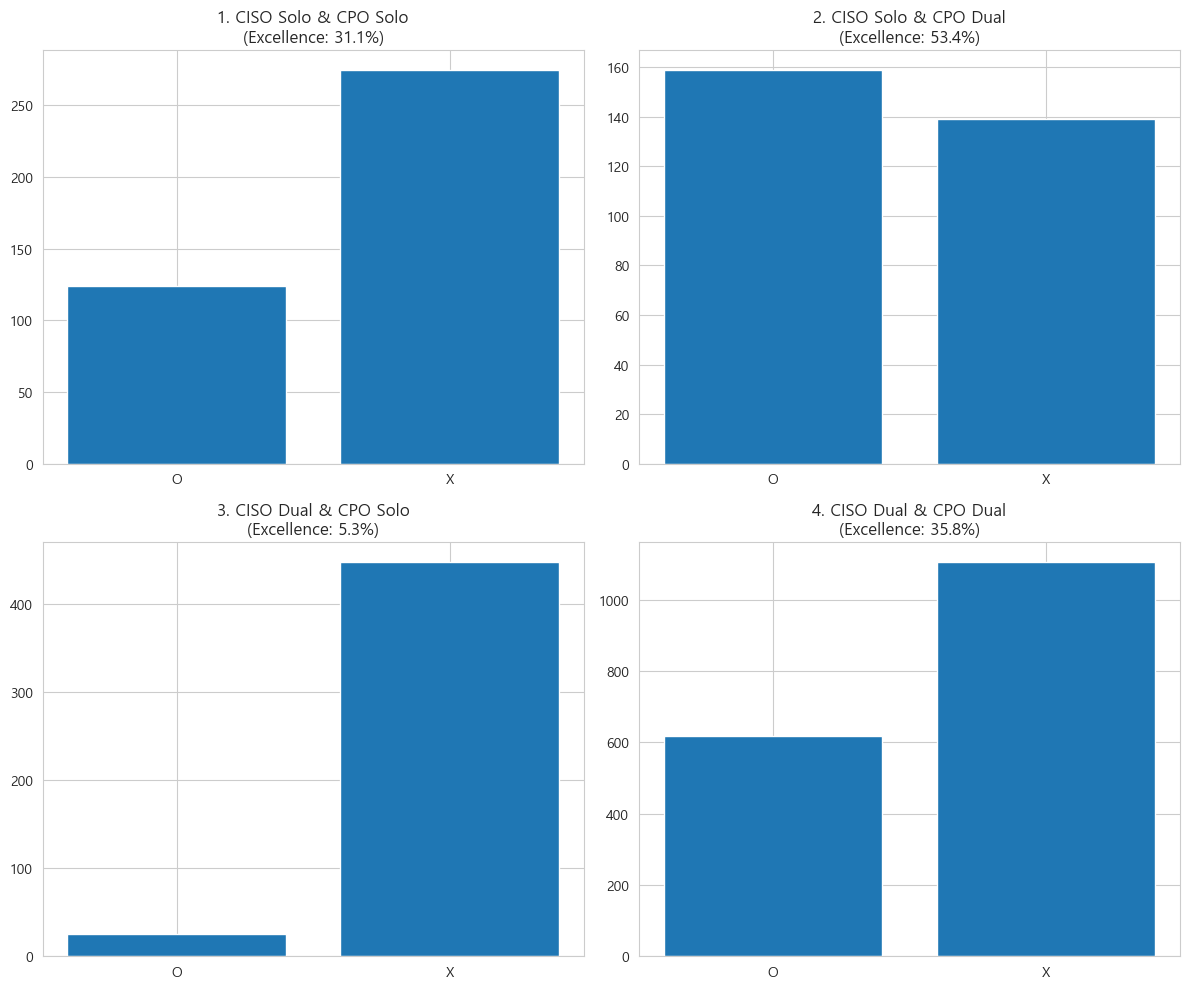

In [84]:
#Column명에 대한 오류가 너무 많아서 데이터 처리를 했습니다!!
def get_real_col_name(df, part_of_name):
    for col in df.columns:
        if part_of_name.lower() in col.lower():
            return col
    return None

ciso_dual = get_real_col_name(df, 'CISO_Dual_Role')
cpo_dual = get_real_col_name(df, 'CPO_Dual_Role')
excel_col = get_real_col_name(df, 'Security_Investment_Excellence')

clean_cols = [ciso_dual, cpo_dual, excel_col]
for col in clean_cols:
    if col:
        df[col] = df[col].astype(str).str.strip().str.upper()

def matrix(ax, data, title):
    if len(data) == 0:
        ax.text(0.5, 0.5, 'Matching Data\nNot Found', ha='center', va='center', color='gray')
        ax.set_title(title)
        return
    counts = data[excel_col].value_counts().reindex(['O', 'X'], fill_value=0)
    total = len(data)
    o_ratio = (counts['O'] / total * 100) if total > 0 else 0
    
    bars = ax.bar(counts.index, counts.values)
    ax.set_title(f"{title}\n(Excellence: {o_ratio:.1f}%)")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

matrix(axes[0, 0], df[(df[ciso_dual] == 'X') & (df[cpo_dual] == 'X')], "1. CISO Solo & CPO Solo")
matrix(axes[0, 1], df[(df[ciso_dual] == 'X') & (df[cpo_dual] == 'O')], "2. CISO Solo & CPO Dual")
matrix(axes[1, 0], df[(df[ciso_dual] == 'O') & (df[cpo_dual] == 'X')], "3. CISO Dual & CPO Solo")
matrix(axes[1, 1], df[(df[ciso_dual] == 'O') & (df[cpo_dual] == 'O')], "4. CISO Dual & CPO Dual")

plt.tight_layout()
plt.show()

3.4 내부 보안 인력 비중이 높은 기업은 보안 투자를 더 많이 하는가?

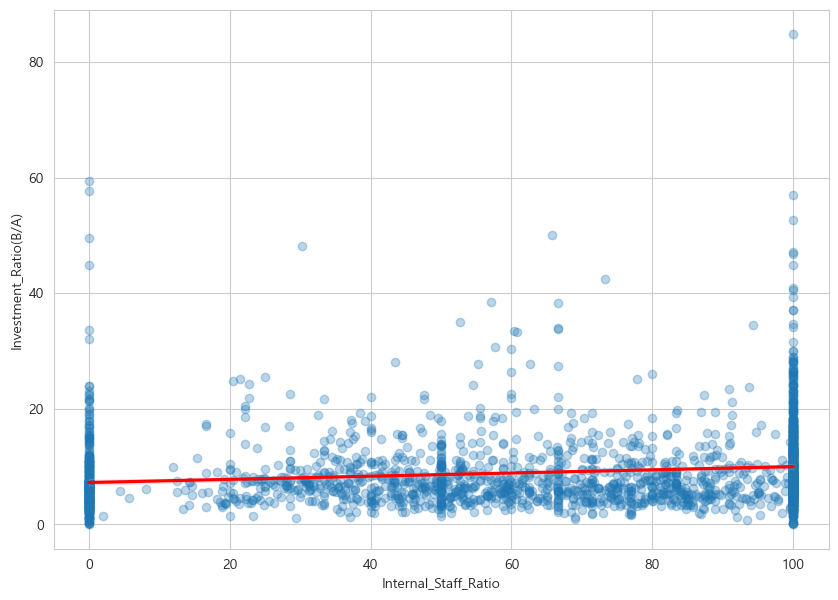

In [93]:
df_staff = df.copy()
df_staff['Internal_Staff_Ratio'] = (df_staff['Internal_Security_Staff'] / df_staff['Security_Workforce(D)']) * 100
plt.figure(figsize=(10, 7))
sns.regplot(data=df_staff, x='Internal_Staff_Ratio', y='Investment_Ratio(B/A)',scatter_kws={'alpha':0.3},line_kws={'color':'red'})
plt.show()